# Week 11: Introduction to Agentic AI

**FYS4411 — Reinforcement Learning and Agentic AI**  
University of Oslo, Department of Physics

*Language models, compound systems, tools, memory, and coordinated action*

This notebook is self-contained and executable. It combines a concise repetition of the lecture, equations, reproducible numerical examples, visual diagnostics, and a short problem set. No API key or external service is required.

In [1]:
import math
import re
from dataclasses import dataclass, field
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(11)
UIO_PURPLE = "#4338B5"
UIO_GREEN = "#2A9D8F"
UIO_RED = "#C84C4C"
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (8.5, 4.8),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.frameon": False,
})

## Learning goals

After completing this notebook, you should be able to

- describe autoregressive language modelling, tokenization, embeddings, attention, and decoding;
- distinguish an LLM, an augmented model call, a workflow, and an agent;
- explain retrieval, tools, memory, verification, planning, and termination as system components;
- formulate an agent as a partially observed sequential decision system;
- implement compact attention, decoding, retrieval, and tool-use examples;
- explain when multiple agents help and when coordination cost dominates;
- evaluate agent trajectories for correctness, cost, provenance, robustness, and safety.

## 1. Autoregressive language models

For tokens $x_{1:T}$, a language model factorizes

$$
p_\theta(x_{1:T})=\prod_{t=1}^{T}p_\theta(x_t\mid x_{<t}).
$$

Training commonly minimizes cross-entropy,

$$
\mathcal L(\theta)=-\sum_{t=1}^{T}\log p_\theta(x_t\mid x_{<t}).
$$

Tokenization defines the discrete interface. Token identifiers index vectors $e_t\in\mathbb R^d$; positional information is added so that order is represented. The model produces logits $z_t\in\mathbb R^{|\mathcal V|}$ and a softmax distribution over the next token.

An LLM is therefore a conditional predictive model. Agency appears only after its outputs are connected to actions and feedback.

### Scaled dot-product attention

For hidden states $H\in\mathbb R^{T\times d}$,

$$
Q=HW_Q,\qquad K=HW_K,\qquad V=HW_V,
$$

and one attention head computes

$$
\operatorname{Attention}(Q,K,V)=
\operatorname{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}+M\right)V.
$$

The causal mask $M_{ij}=-\infty$ for $j>i$ prevents position $i$ from using future tokens. Multi-head attention repeats this operation with different learned projections. Residual connections, normalization, and a position-wise feed-forward network complete a transformer block.

In [2]:
# A small, fully transparent causal-attention calculation.
attention_rng=np.random.default_rng(110)
tokens=np.array(["a", "scientific", "agent", "calls", "a", "tool"])
d_model,d_key=8,5
H=attention_rng.normal(0,1,(len(tokens),d_model))
# Repeated tokens share a component, as they would under a token embedding.
H[4]=H[0]+attention_rng.normal(0,.08,d_model)
Wq=attention_rng.normal(0,1/np.sqrt(d_model),(d_model,d_key))
Wk=attention_rng.normal(0,1/np.sqrt(d_model),(d_model,d_key))
Wv=attention_rng.normal(0,1/np.sqrt(d_model),(d_model,d_key))
Q,K,V_att=H@Wq,H@Wk,H@Wv
logits_att=Q@K.T/np.sqrt(d_key)
causal_mask=np.triu(np.ones_like(logits_att,dtype=bool),k=1)
logits_att[causal_mask]=-np.inf
shifted=logits_att-np.max(logits_att,axis=1,keepdims=True)
weights_att=np.exp(shifted);weights_att/=weights_att.sum(axis=1,keepdims=True)
attended=weights_att@V_att
print("attention matrix shape:",weights_att.shape)
print("output representation shape:",attended.shape)

attention matrix shape: (6, 6)
output representation shape: (6, 5)


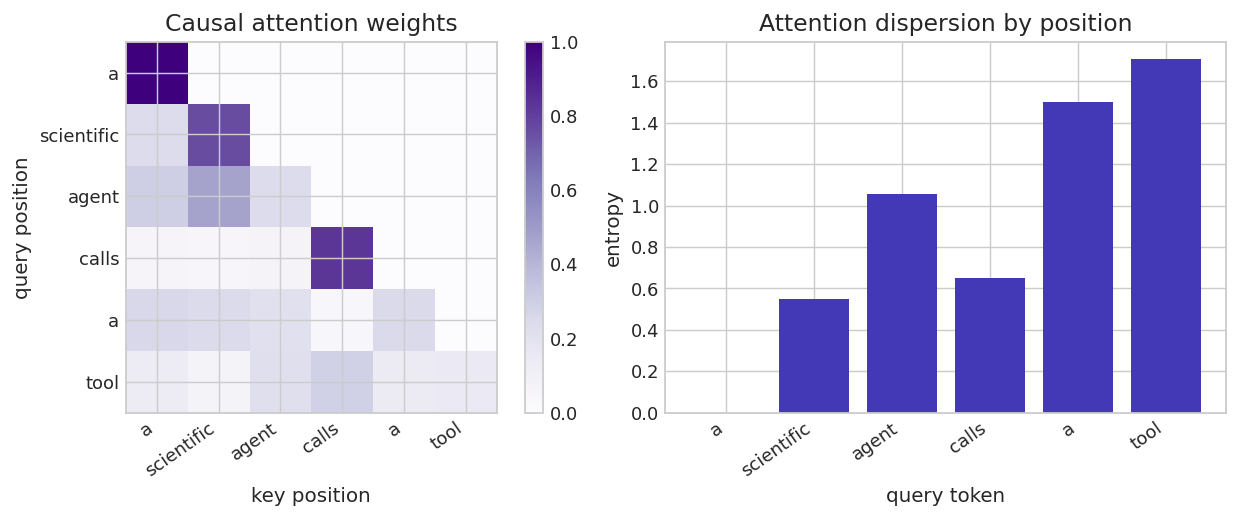

In [3]:
fig,axes=plt.subplots(1,2,figsize=(10.5,4.1))
im=axes[0].imshow(weights_att,cmap="Purples",vmin=0,vmax=weights_att.max())
axes[0].set_xticks(range(len(tokens)),tokens,rotation=35,ha="right")
axes[0].set_yticks(range(len(tokens)),tokens)
axes[0].set(title="Causal attention weights",xlabel="key position",ylabel="query position")
fig.colorbar(im,ax=axes[0],fraction=.046)

entropy_att=-np.sum(weights_att*np.log(weights_att+1e-12),axis=1)
axes[1].bar(np.arange(len(tokens)),entropy_att,color=UIO_PURPLE)
axes[1].set_xticks(range(len(tokens)),tokens,rotation=35,ha="right")
axes[1].set(title="Attention dispersion by position",ylabel="entropy",xlabel="query token")
plt.tight_layout();plt.show()

The plot visualizes one randomly initialized head, not a claim about the internal attention of a trained model. Attention weights are computational routing coefficients; they are not automatically faithful explanations of a model's reasoning.

## 2. Generation and decoding

Generation repeatedly samples or selects from

$$
p_T(x_i)=\frac{\exp(z_i/T)}{\sum_j\exp(z_j/T)}.
$$

Lower temperature $T$ concentrates probability on high-logit tokens; higher temperature increases diversity. Top-$k$ and nucleus sampling truncate the distribution before sampling. Greedy decoding is reproducible but can commit early to a poor continuation; sampling explores alternatives but increases variance.

Decoding is a system choice. It changes behavior without changing model parameters.

In [4]:
vocabulary=np.array(["retrieve","calculate","simulate","answer","ask","stop"])
base_logits=np.array([1.8,1.45,1.25,1.0,.35,-.1])
temperatures=[.35,.75,1.4]
decode_rng=np.random.default_rng(111)
decoding_rows=[]
probability_by_temperature={}
for temperature in temperatures:
    probabilities=np.exp(base_logits/temperature-np.max(base_logits/temperature))
    probabilities/=probabilities.sum()
    probability_by_temperature[temperature]=probabilities
    samples=decode_rng.choice(vocabulary,size=2500,p=probabilities)
    decoding_rows.append({"temperature":temperature,
                          "entropy":-np.sum(probabilities*np.log(probabilities)),
                          "unique actions":len(np.unique(samples)),
                          "most frequent":pd.Series(samples).value_counts().index[0]})
print(pd.DataFrame(decoding_rows).to_string(index=False,float_format=lambda z:f"{z:.3f}"))

 temperature  entropy  unique actions most frequent
       0.350    1.128               6      retrieve
       0.750    1.542               6      retrieve
       1.400    1.703               6      retrieve


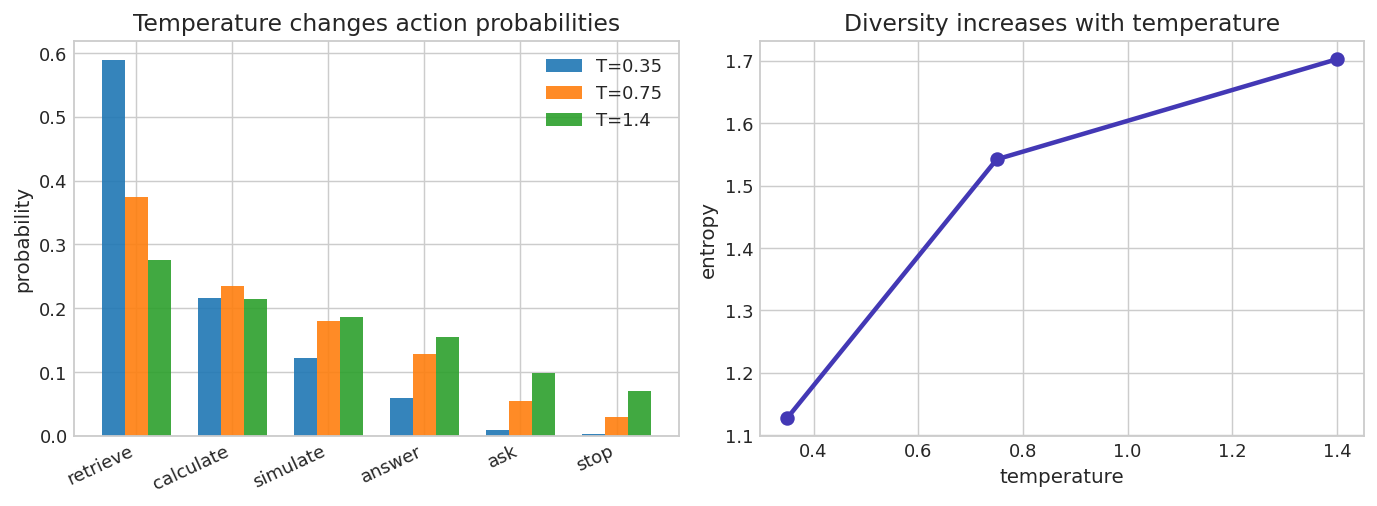

In [5]:
fig,axes=plt.subplots(1,2,figsize=(10.7,4.0))
xloc=np.arange(len(vocabulary));width=.24
for i,temperature in enumerate(temperatures):
    axes[0].bar(xloc+(i-1)*width,probability_by_temperature[temperature],width,
                label=f"T={temperature}",alpha=.9)
axes[0].set_xticks(xloc,vocabulary,rotation=25,ha="right")
axes[0].set(title="Temperature changes action probabilities",ylabel="probability")
axes[0].legend()
entropies=[-np.sum(p*np.log(p)) for p in probability_by_temperature.values()]
axes[1].plot(temperatures,entropies,"o-",color=UIO_PURPLE,lw=2.5,ms=7)
axes[1].set(title="Diversity increases with temperature",xlabel="temperature",ylabel="entropy")
plt.tight_layout();plt.show()

### Pretraining, post-training, and in-context learning

Pretraining creates broad representations through next-token prediction. Post-training shapes instruction following, preferences, refusal behavior, tool calling, and other policies. In-context learning conditions behavior on instructions, examples, retrieved passages, and tool results **without updating the model parameters**.

The context window is finite working state. It must contain competing objects: task instructions, evidence, tools, intermediate results, and conversation history. Long context does not guarantee correct retrieval or reasoning; context selection is itself an engineering problem.

## 3. From model call to compound AI system

| System form | Who determines the next step? | Best fit |
|---|---|---|
| model call | caller | one transformation or answer |
| fixed workflow | developer-defined graph | stable, repeatable process |
| bounded agent | model within explicit actions and limits | uncertain path, testable feedback |
| multi-agent system | several controllers plus protocol | genuine specialization or parallelism |

A compound system may combine

$$
\text{model}+\text{retrieval}+\text{tools}+\text{code execution}
+\text{memory}+\text{verifiers}+\text{human oversight}.
$$

This decomposition matters because the system can improve by changing retrieval, schemas, control logic, or evaluation without retraining the base model.

## 4. Retrieval as controlled external knowledge

Retrieval-augmented generation selects evidence $z_{1:k}$ for a query $q$ and conditions generation on both:

$$
p(y\mid q)=\sum_z p_\eta(z\mid q)p_\theta(y\mid q,z).
$$

Retrieval improves traceability only when sources are relevant, quoted in context, and checked. A retrieved passage is an observation—not automatically a fact.

The next cell implements a small TF-IDF retriever without an external service.

 rank  similarity                                                                               document
    1       0.706       A tool-using agent selects structured actions, observes results, and may replan.
    2       0.100 A self-driving laboratory chooses experiments, measures outcomes, and updates a model.
    3       0.093    Q-learning estimates action values using a bootstrapped temporal-difference target.


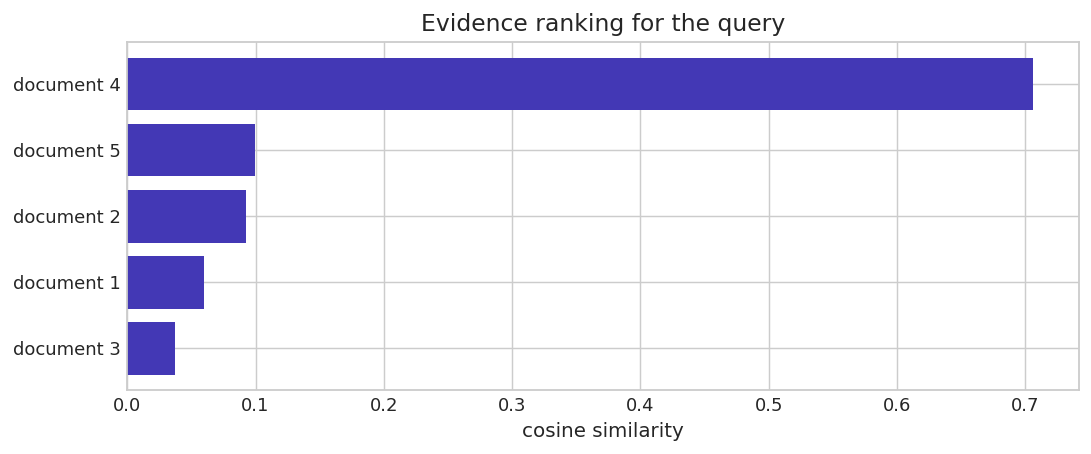

In [6]:
documents=[
    "A PINN minimizes data error together with a differential-equation residual.",
    "Q-learning estimates action values using a bootstrapped temporal-difference target.",
    "AlphaFold predicts protein structure and reports confidence; it is not by itself an agent.",
    "A tool-using agent selects structured actions, observes results, and may replan.",
    "A self-driving laboratory chooses experiments, measures outcomes, and updates a model.",
]
query="A tool-using system selects structured actions, observes results, and replans."

def tokenize_simple(text):
    return re.findall(r"[a-z]+",text.lower())

all_text=documents+[query]
vocab=sorted(set(word for text in all_text for word in tokenize_simple(text)))
word_index={word:i for i,word in enumerate(vocab)}
counts=np.zeros((len(all_text),len(vocab)))
for row,text in enumerate(all_text):
    for word in tokenize_simple(text):counts[row,word_index[word]]+=1
document_frequency=np.sum(counts[:len(documents)]>0,axis=0)
idf=np.log((1+len(documents))/(1+document_frequency))+1
tfidf=counts*idf
tfidf/=np.linalg.norm(tfidf,axis=1,keepdims=True)+1e-12
similarities=tfidf[:-1]@tfidf[-1]
ranking=np.argsort(similarities)[::-1]
retrieval_table=pd.DataFrame({"rank":np.arange(1,len(documents)+1),
                              "similarity":similarities[ranking],
                              "document":[documents[i] for i in ranking]})
print(retrieval_table.head(3).to_string(index=False,float_format=lambda z:f"{z:.3f}"))

plt.figure(figsize=(8.5,3.6))
plt.barh(np.arange(len(documents)),similarities[ranking][::-1],color=UIO_PURPLE)
plt.yticks(np.arange(len(documents)),[f"document {i+1}" for i in ranking[::-1]])
plt.xlabel("cosine similarity");plt.title("Evidence ranking for the query")
plt.tight_layout();plt.show()

Lexical retrieval misses paraphrases and domain relationships; embedding retrievers can improve semantic matching but introduce their own training-domain and calibration assumptions. Hybrid retrieval, metadata filters, reranking, and source-level evaluation are common extensions.

## 5. Agentic flow as a partially observed decision process

An LLM-based agent repeatedly selects from an admissible action set until it finishes, aborts, or escalates. A useful formal model is a POMDP,

$$
(\mathcal S,\mathcal A,P,\mathcal O,O,r,\gamma),
$$

with maintained state

$$
m_t=f(m_{t-1},o_t,a_{t-1}).
$$

A typical loop is

$$
\text{sense}\rightarrow\text{update state}\rightarrow\text{plan/select}
\rightarrow\text{act}\rightarrow\text{verify}\rightarrow\text{replan or stop}.
$$

Natural-language goals should be translated into acceptance tests, constraints, budgets, and approval boundaries. Termination is a decision among `continue`, `finish`, `abort`, and `escalate`.

### Tool calls are typed actions

A tool definition should specify name, description, argument types, valid ranges, return format, side effects, failure modes, and required permissions. Scientific tools should additionally expose units, numerical tolerances, provenance, and uncertainty.

```python
tool = {
    "name": "propagate_qubit",
    "arguments": {"detuning": "float", "duration": "float > 0"},
    "returns": {"probability_1": "float in [0, 1]"},
    "side_effects": "none",
    "verification": "probability bounds and norm preservation"
}
```

The execution boundary should parse and validate the model decision before any external action is taken.

In [7]:
# A framework-independent tool loop. The controller is transparent so that
# the control semantics, rather than a particular API, remain visible.
knowledge={"rabi formula":"For resonant drive, P1(t)=sin^2(Omega t / 2)."}

def retrieve_tool(topic):
    return {"status":"ok","evidence":knowledge.get(topic,"not found"),"source":"course note"}

def calculator_tool(expression):
    allowed={"sin":np.sin,"pi":np.pi}
    value=eval(expression,{"__builtins__":{}},allowed)
    return {"status":"ok","value":float(value)}

task_state={"question":"Compute P1 for Omega=1 and t=pi.","evidence":None,"answer":None}
trajectory=[]
for step in range(5):
    if task_state["evidence"] is None:
        action={"tool":"retrieve","topic":"rabi formula"}
        observation=retrieve_tool(action["topic"]);task_state["evidence"]=observation
    elif task_state["answer"] is None:
        action={"tool":"calculator","expression":"sin(pi/2)**2"}
        observation=calculator_tool(action["expression"]);task_state["answer"]=observation["value"]
    else:
        action={"tool":"finish"};observation={"status":"ok","answer":task_state["answer"]}
    trajectory.append({"step":step,"action":action["tool"],"observation":observation})
    if action["tool"]=="finish":break
print(pd.DataFrame([{"step":x["step"],"action":x["action"],"status":x["observation"]["status"]}
                    for x in trajectory]).to_string(index=False))
print("verified answer:",task_state["answer"],"within [0,1]:",0<=task_state["answer"]<=1)

 step     action status
    0   retrieve     ok
    1 calculator     ok
    2     finish     ok
verified answer: 1.0 within [0,1]: True


The example is deliberately small. A real controller would not evaluate arbitrary expressions with `eval`; it would use an allow-listed parser or numerical function with a fixed schema. Sandboxing, permission checks, and normalized observations belong outside the model.

## 6. Planning, reflection, search, and verification

- **Planning** identifies dependencies, missing information, action costs, and revision triggers.
- **Replanning** is appropriate when observations contradict the predicted state.
- **Reflection** revises a candidate using explicit feedback; ungrounded self-critique may merely add text.
- **Search** evaluates several candidate trajectories rather than committing to the first.
- **Verification** maps an artifact and specification to diagnostic evidence.

Tests are feedback, not a complete reward. A system that passes incomplete tests may still violate the scientific requirement.

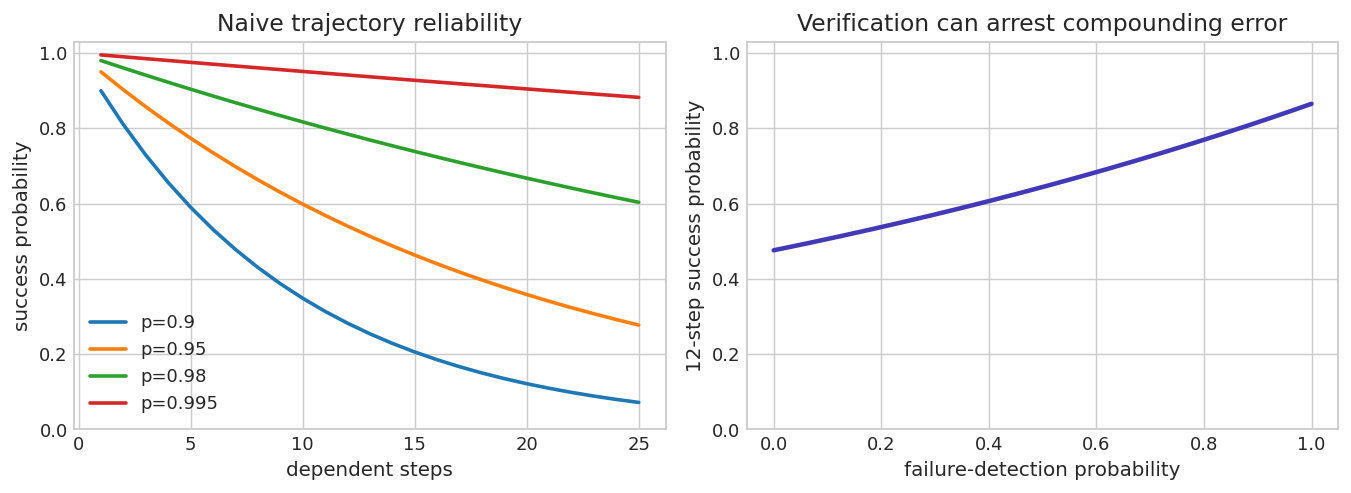

In [8]:
# Independent-step reliability is simplified, but it exposes why long
# trajectories need verification, retries, and decomposition.
steps=np.arange(1,26)
per_step=[.90,.95,.98,.995]
fig,axes=plt.subplots(1,2,figsize=(10.5,3.9))
for probability in per_step:
    axes[0].plot(steps,probability**steps,lw=2,label=f"p={probability}")
axes[0].set(title="Naive trajectory reliability",xlabel="dependent steps",ylabel="success probability",ylim=(0,1.03))
axes[0].legend()

p=.94
verifier_detection=np.linspace(0,1,150)
# A detected failure is corrected successfully with probability 0.8.
effective=p+(1-p)*verifier_detection*.8
axes[1].plot(verifier_detection,effective**12,color=UIO_PURPLE,lw=2.5)
axes[1].set(title="Verification can arrest compounding error",xlabel="failure-detection probability",
            ylabel="12-step success probability",ylim=(0,1.03))
plt.tight_layout();plt.show()

Independence is not realistic: errors can be correlated through shared context, tools, or assumptions. The calculation is therefore a warning, not a reliability estimate. Correlated failures make independent verification and diverse evidence especially important.

## 7. Multi-agent systems

A multi-agent system contains decision makers $i\in\{1,\ldots,n\}$ that exchange typed messages or update shared state. Common motivations are context isolation, role specialization, parallel search, and independent critique.

| Topology | Strength | Main risk |
|---|---|---|
| supervisor-workers | clear ownership and aggregation | bottleneck and hidden worker errors |
| peer network | flexible collaboration | duplicated work and consensus drift |
| shared blackboard | asynchronous evidence integration | stale or conflicting shared state |

Messages should transmit claims, evidence, uncertainty, dependencies, and requested action—not unrestricted private reasoning. Multiple agents do not create independent evidence when they share the same data and model failure modes.

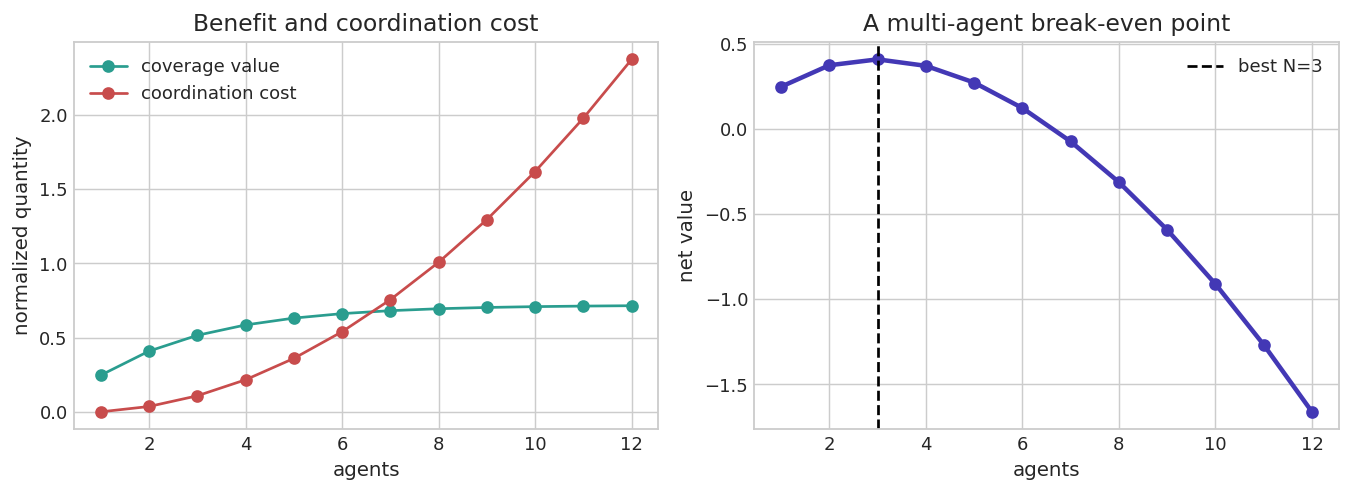

In [9]:
# Stylized break-even calculation for parallel specialists.
n_agents=np.arange(1,13)
task_difficulty=.72
coverage_gain=1-np.exp(-.42*n_agents)
coordination_cost=.018*n_agents*(n_agents-1)
expected_value=task_difficulty*coverage_gain-coordination_cost
best_n=int(n_agents[np.argmax(expected_value)])

fig,axes=plt.subplots(1,2,figsize=(10.5,3.9))
axes[0].plot(n_agents,task_difficulty*coverage_gain,"o-",color=UIO_GREEN,label="coverage value")
axes[0].plot(n_agents,coordination_cost,"o-",color=UIO_RED,label="coordination cost")
axes[0].set(title="Benefit and coordination cost",xlabel="agents",ylabel="normalized quantity")
axes[0].legend()
axes[1].plot(n_agents,expected_value,"o-",color=UIO_PURPLE,lw=2.5)
axes[1].axvline(best_n,color="black",ls="--",label=f"best N={best_n}")
axes[1].set(title="A multi-agent break-even point",xlabel="agents",ylabel="net value")
axes[1].legend()
plt.tight_layout();plt.show()

The curves are illustrative. A real decision requires measured task success, latency, token and tool cost, communication failures, and error correlation. A multi-agent architecture is justified only when the marginal value of specialization or parallelism exceeds coordination cost.

## 8. Applications and evaluation

Coding agents operate against executable repository state. Research agents connect literature, code, simulation, and evidence. Systems such as AI co-scientist, Virtual Lab, AlphaEvolve, and AI Scientist illustrate hypothesis refinement, role specialization, program search, and end-to-end computational loops. Their scientific value depends on external validation, not architectural novelty alone.

Evaluate the complete trajectory

$$
\tau=(o_0,a_0,o_1,a_1,\ldots,o_T),
$$

including task success, tool correctness, provenance, cost, latency, reproducibility, robustness, safety violations, and human effort. Logs should preserve normalized observations, tool versions, decisions, approval events, artifacts, and termination reasons.

## Design checklist

1. Specify the task contract and acceptance evidence.
2. Define observations, maintained state, actions, and side effects.
3. Use the least autonomous architecture that handles path uncertainty.
4. Validate tool arguments and normalize all results.
5. Separate working context, persistent memory, and authoritative data.
6. Define budgets, stopping rules, fallback behavior, and approval gates.
7. Evaluate trajectories over seeds, perturbations, and tool failures.
8. Version prompts, models, code, data, tools, and produced artifacts.

## Problem set

1. Derive the dimensions of $QK^\top$ and the attention output for $H\in\mathbb R^{T\times d}$.
2. Replace the random attention head by two heads. What information can be represented that one head cannot express as easily?
3. Implement top-$k$ and nucleus sampling for the decoding example. Compare entropy and action coverage.
4. Add stemming or bigrams to the retriever. Construct one query for which lexical retrieval still fails.
5. Express the tool loop as a finite-state controller with `abort` and `escalate` states.
6. Define a value-of-information rule for deciding whether to retrieve before answering.
7. Replace independent failures in the reliability example by a latent shared failure variable. Compare trajectory reliability.
8. Design a typed message schema for a planner, coding agent, and critic.
9. Propose an evaluation in which a single-agent and multi-agent system receive identical tool, time, and compute budgets.

**Mini-project.** Build a bounded research agent with retrieval, one numerical tool, persistent structured memory, a verifier, and an approval gate. Evaluate at least 30 tasks, including irrelevant retrievals and tool failures. Report trajectory-level success, cost, provenance, and abstention behavior.

## Summary

- LLMs are autoregressive predictive models built from tokenization, embeddings, transformer blocks, and decoding rules.
- Agentic AI begins when model outputs are interpreted as actions inside a controlled feedback loop.
- Compound systems add dynamic knowledge, testable tools, memory, verification, and human decision boundaries.
- Agentic flow is naturally analyzed as partial observation, maintained state, action selection, feedback, and termination.
- Multi-agent systems provide specialization and parallelism only when coordination cost and correlated failure are controlled.
- Scientific and industrial agents must be evaluated on trajectories, evidence, reproducibility, cost, and safety.

**Further reading:** Lecture 11; [Agents for Science curriculum](https://agents4science.github.io/Class/curriculum.html); Yao et al., [ReAct](https://arxiv.org/abs/2210.03629); Zaharia et al., [Compound AI Systems](https://bair.berkeley.edu/blog/2024/02/18/compound-ai-systems/).